In [88]:
# to_save, to_load = False, True
session_file = "./tmp/TIC_396335613_EA.ipynb.pkl"

# # load/save the notebook session
# # https://dill.readthedocs.io/en/latest/
# if True: 
#     import dill
#     import sys
#     if "../" not in sys.path:  # to get my usual helpers at base dir
#         sys.path.append("../")
#     if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#         sys.path.append("../eb_with_diff_sb_period/etv/")
#     dill.load_module(session_file)
#     print(f"Notebook session loaded from  {session_file}")

# if True:  # save the notebook session
#     import dill
#     dill.dump_module(session_file)
#     print(f"Notebook session saved in {session_file}")


Notebook session saved in ./tmp/TIC_396335613_EA.ipynb.pkl


In [1]:
import sys
if "../" not in sys.path:  # to get my usual helpers at base dir
    sys.path.append("../")

import lightkurve as lk
from lightkurve_ext import of_sector, of_sectors, of_2min_cadences
import lightkurve_ext as lke
from lightkurve_ext import TransitTimeSpec, TransitTimeSpecList
import lightkurve_ext_tess as lket
import lightkurve_ext_pg as lke_pg
import lightkurve_ext_pg_runner as lke_pg_runner
import tic_plot as tplt

import asyncio_compat

import math
import re
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib

import pandas as pd
import astropy as astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.io import fits

from matplotlib.ticker import (FormatStrFormatter, AutoMinorLocator)

from importlib import reload # useful during development to reload packages

from IPython.display import display, HTML, Javascript, clear_output

display(HTML("<style>.container { width:99% !important; }</style>"))  # Jupyter 6
display(HTML("<style>.jp-Notebook { --jp-notebook-max-width: 98%; }</style>"))  # Jupyter 7


# No longer works in Jupyter 7+
display(Javascript("""
// export notebook url to Python for bokeh-based interactive features
if (window["IPython"] != null) {
  IPython.notebook.kernel.execute(`notebook_url = "${window.location.origin}"`);
} else {
  console.warn("IPython js object not available (in Jupyter 7). Hardcode notebook_url in the notebook itself instead.")
}
"""));
notebook_url = "localhost:8888"

%matplotlib inline

# data cache config
lk_download_dir = '../data'
if hasattr(lk, "conf"):  # default download dir
    lk.conf.cache_dir = lk_download_dir

# make markdown table aligned to the left of the cell output (instead of center)
display(HTML("<style>table {margin-left: 4ch;}</style>"))

<IPython.core.display.Javascript object>

# TIC 396335613 Analysis (EA)

- new VSX entry

## TESS Data

In [19]:
tic = 396335613

sr = lk.search_lightcurve(f"TIC{tic}", )  # author="SPOC", cadence="short"
sr_unfiltered = sr  # keep a copy
sr = lke.filter_by_priority(sr, author_priority = ["SPOC", "TESS-SPOC", "QLP"])  # "SPOC", "TESS-SPOC", 
# sr = sr[sr.author == "QLP"]  # for uniformity, only 1 sector (3) has no QLP data
# sr = lke._sort_chronologically(sr)

astropy.table.pprint.conf.max_lines = 100  # to print all rows
display(sr)

# Note: only 1 sector of ready made lightcurve
# if needed, lightcurves can be created from sectors 37, 63, 64 (and in the future 90, 99, 100, 101)
lcc_tess = sr.download_all()
lcc_tess

#,mission,year,author,exptime,target_name,distance,proposal_id
,,,,s,,arcsec,
0,TESS Sector 55,2022,SPOC,120,396335613,0.0,N/A
1,TESS Sector 81,2024,SPOC,120,396335613,0.0,N/A
2,TESS Sector 82,2024,SPOC,120,396335613,0.0,N/A


LightCurveCollection of 3 objects:
    0: <TessLightCurve LABEL="TIC 396335613" SECTOR=55 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 396335613" SECTOR=81 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 396335613" SECTOR=82 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>

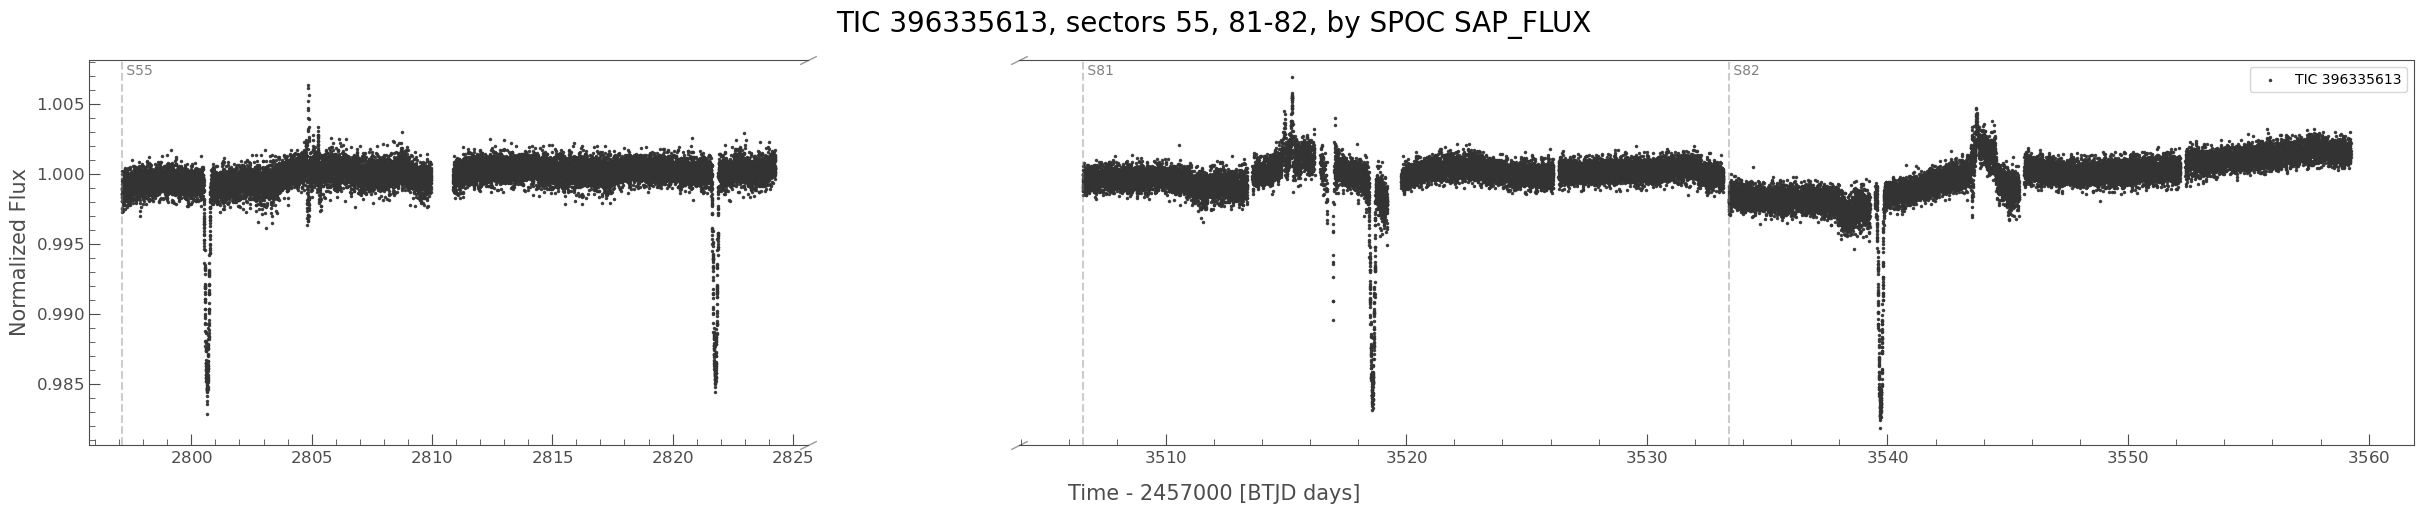

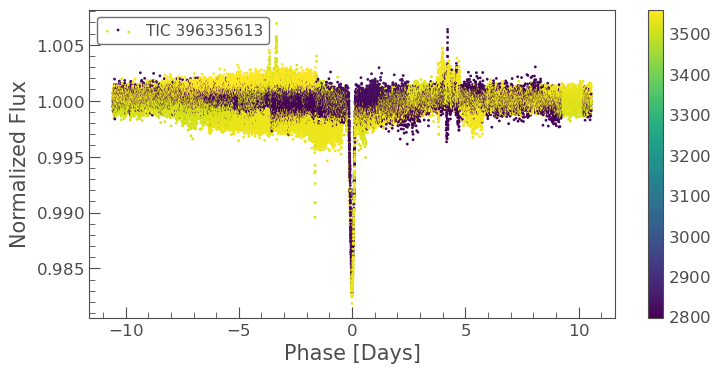

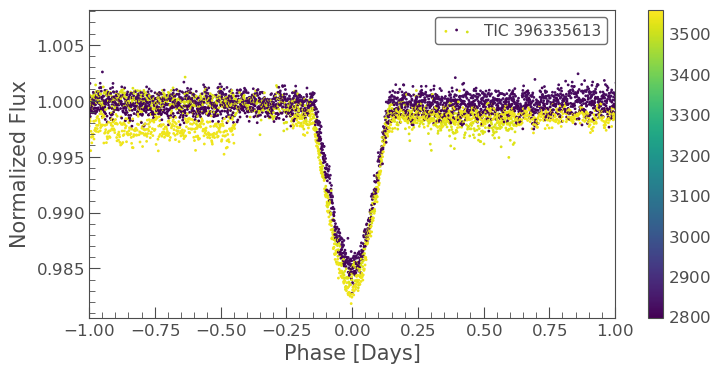

In [22]:
_lc = lke.stitch(lcc_tess, corrector_func=lambda lc: lc.select_flux("sap_flux").normalize(), ignore_incompatible_column_warning=True)  # 

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author} {_lc.flux_origin.upper()}", fontsize=20);
# [ax.set_ylim(0.97, 1.01) for ax in axs];

_lc_f = _lc.fold(period=21.116, epoch_time=Time(3539.71, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);

ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
ax.set_xlim(-1, 1);
# ax.set_ylim(0.97, 1.01); 
# ax.set_xlim(5, 10); ax.set_ylim(0.95, None);  # zoomed around Min II

### Compare the lightcurves from different products

Decision: use SPOC SAP_FLUX. So no need to explain why SPOC SAP_FLUX is used. 
SPOC PCDSAP_FLUX is used as a reference to mask out unreliable data


- SPOC PDCSAP_FLUX: cleaner but misses 2 eclipses

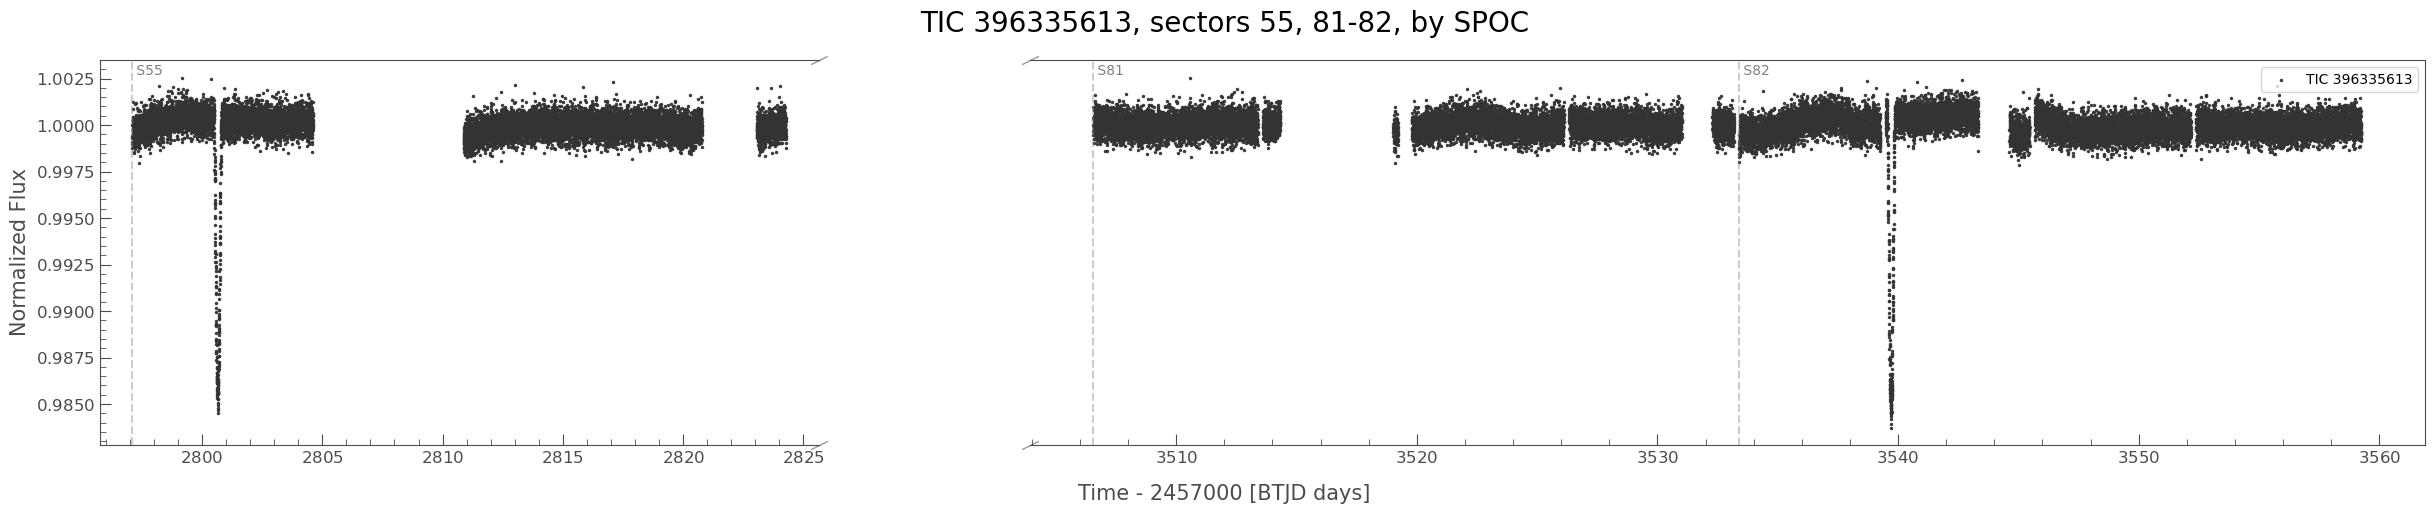

- SPOC SAP_FLUX:  messier but has 2 additional eclipses

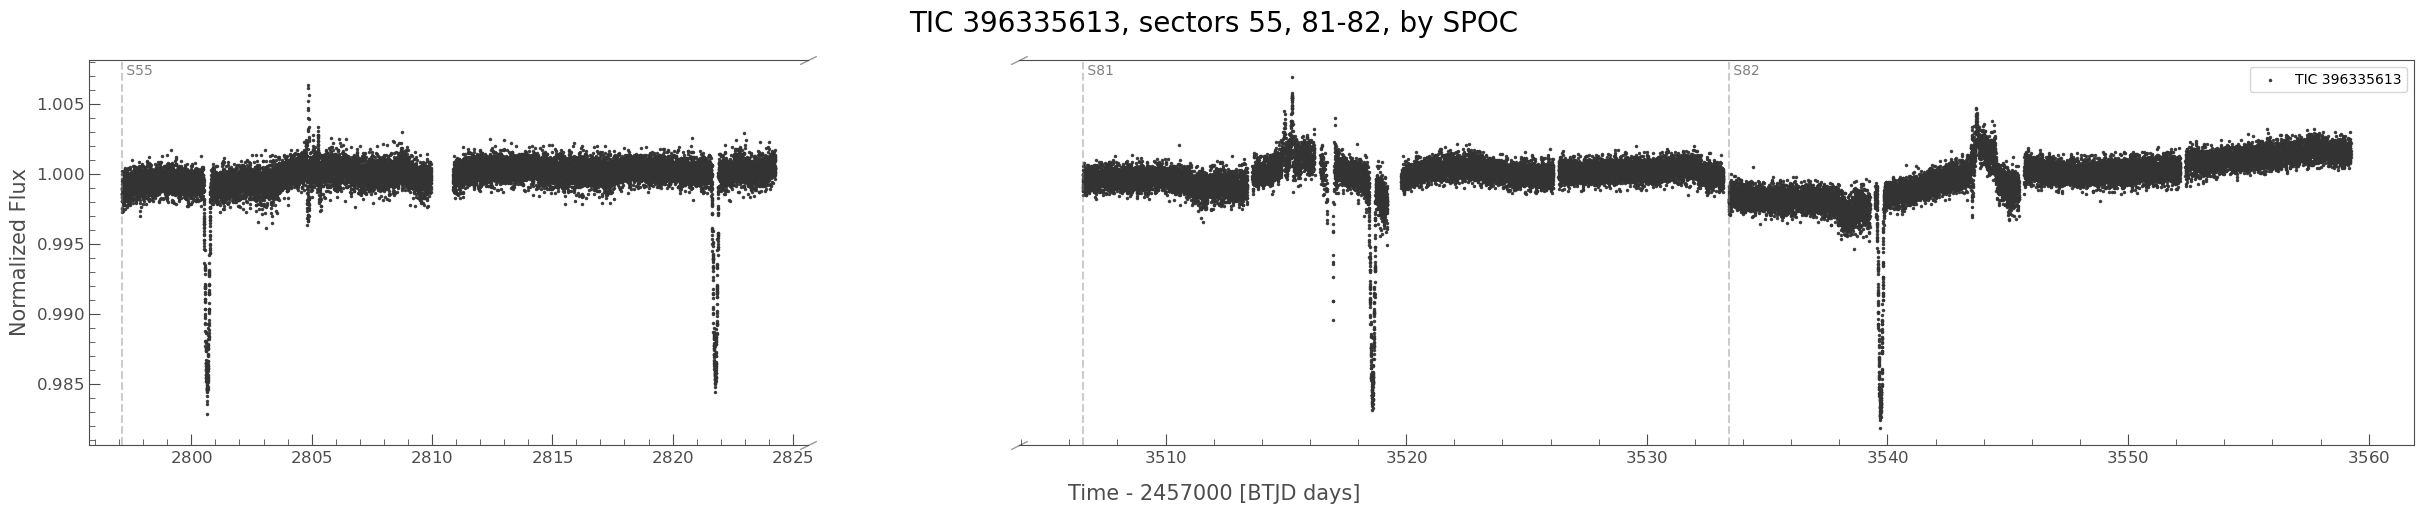

- QLP SAP_FLUX: similar to SPOC SAP_FLUX

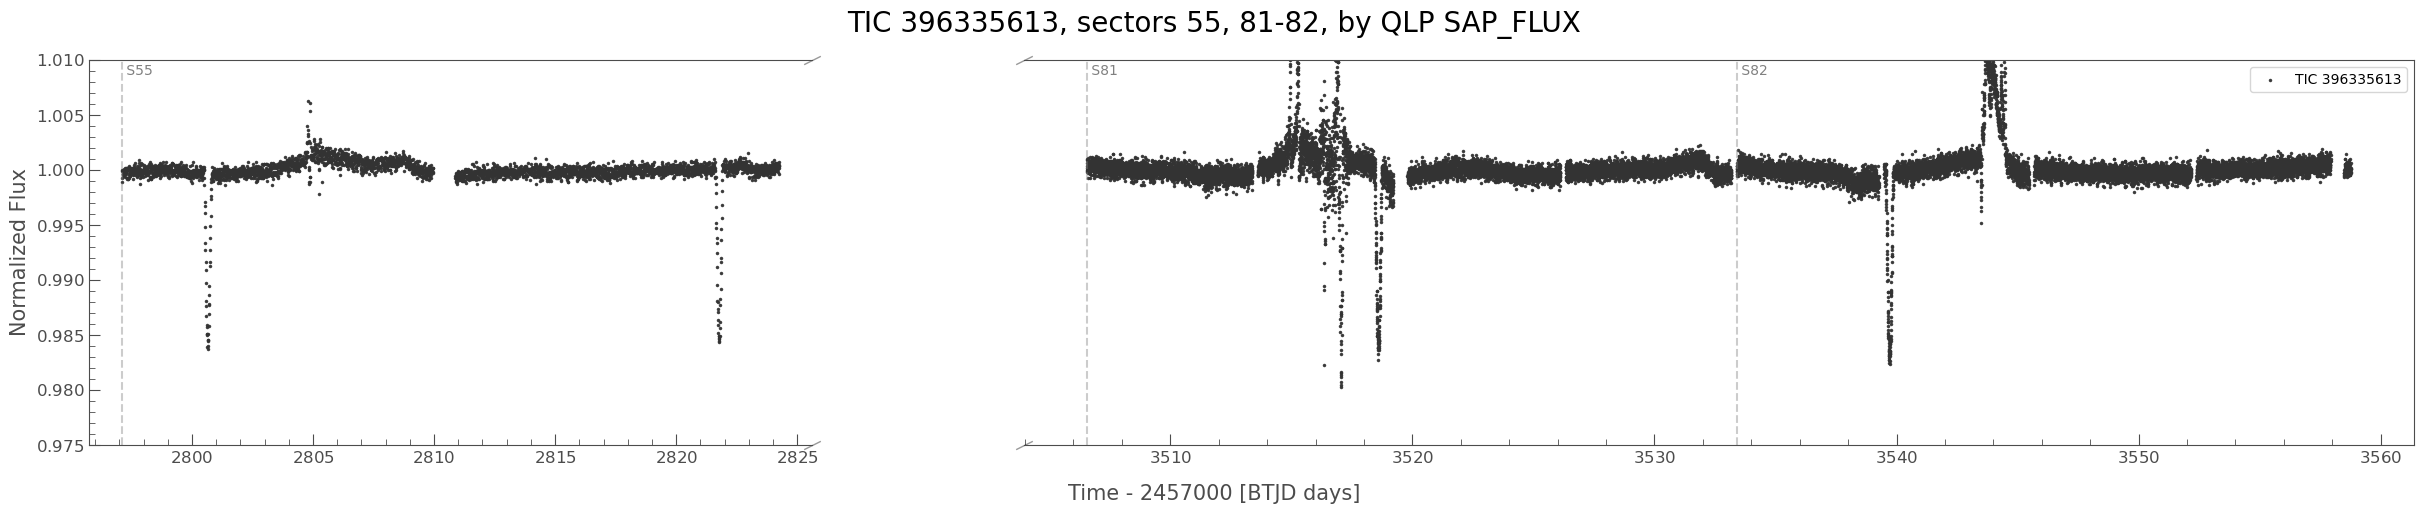

- QLP DET_FLUX: 

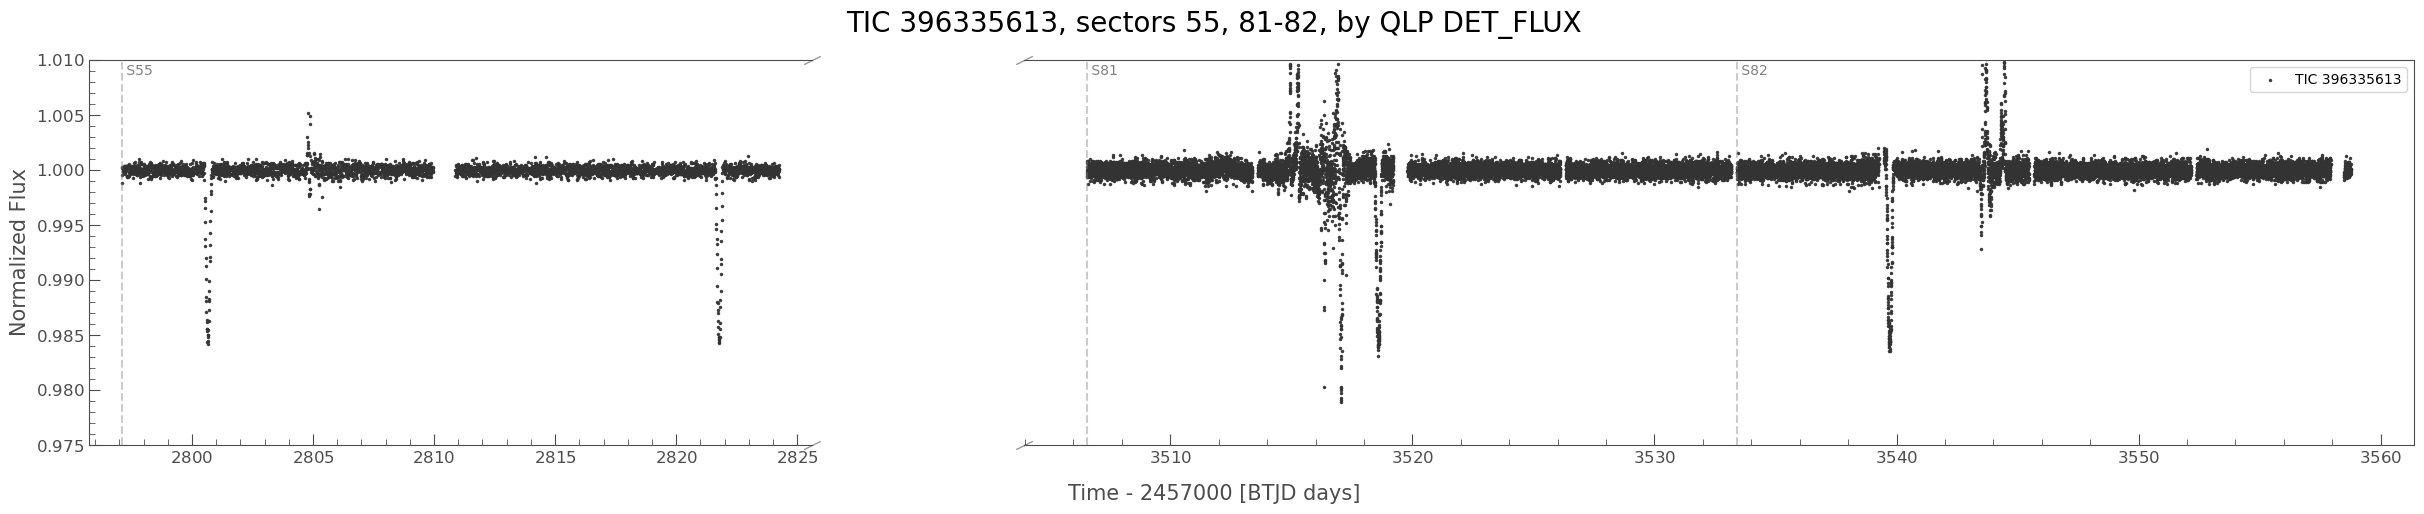


In [ ]:
# truncating the eclipses to see out of eclipse variation

# _ylim = (0.97, 1.01)
# axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
# axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author} ", fontsize=20);
# [ax.set_ylim(*_ylim) for ax in axs];

# ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
# ax.set_ylim(*_ylim);

### Contamination (in TESS Pixels) N/A


## Gaia DR3 info (coordinate, etc.)

In [23]:
# reload(lke)
# reload (lket)
rs_all_cols, rs, rs_html  = lket.search_gaiadr3_of_tics(tic, radius_arcsec=15, magnitude_range=None,  pm_error_factor=None, pm_range_fraction=None, pm_range_minimum=None, 
                                                        calc_separation_from_first_row=True,  # assuming the first row is the target, it'd calculate more accurately the separation for Gaia DR3 Main
                                                        compact_columns=True, also_return_html=True, also_return_astrophysical=False, verbose_html=True, include_nss_summary_in_html=False)
display(HTML(rs_html))

# from Gaia DR3
target_coord = SkyCoord(rs[0]["RAJ2000"], rs[0]["DEJ2000"], unit=(u.deg, u.deg), frame="icrs")
target_coord_dict = dict(ra=target_coord.ra.value, dec=target_coord.dec.value)


In [25]:
primary_name = f"TIC {tic}" # bright star; has HD name, but we only use TESS data so keep TIC as the name
primary_name  

'TIC 396335613'

## Combining all data (TESS only)

- ASAS-3 : data does not have the photometric precision
  - https://www.astrouw.edu.pl/cgi-asas/asas_variable/205550+0323.6,asas3,21.116,-3460.29,500,900,0


### TESS: remove outliers / systemaitcs; convert to mag and HJD


In [30]:
# helper to review the data interactively
_lc = lke.stitch(lcc_tess, corrector_func=lambda lc: lc.select_flux("sap_flux").normalize(), ignore_incompatible_column_warning=True)  # 
tplt.plot_transit_interactive(_lc, figsize=(30, 8), plot_kwargs=dict(normalize=False, plot_kwargs=dict(s=25),));

Output(layout=Layout(border_bottom='1px solid lightgray', border_left='1px solid lightgray', border_right='1px…

Output(layout=Layout(padding='1em'))

The cached HJD time in ../data/hjd/hjd_TIC_396335613_SPOC_55_81_82.txt has different length. discard it.


45116

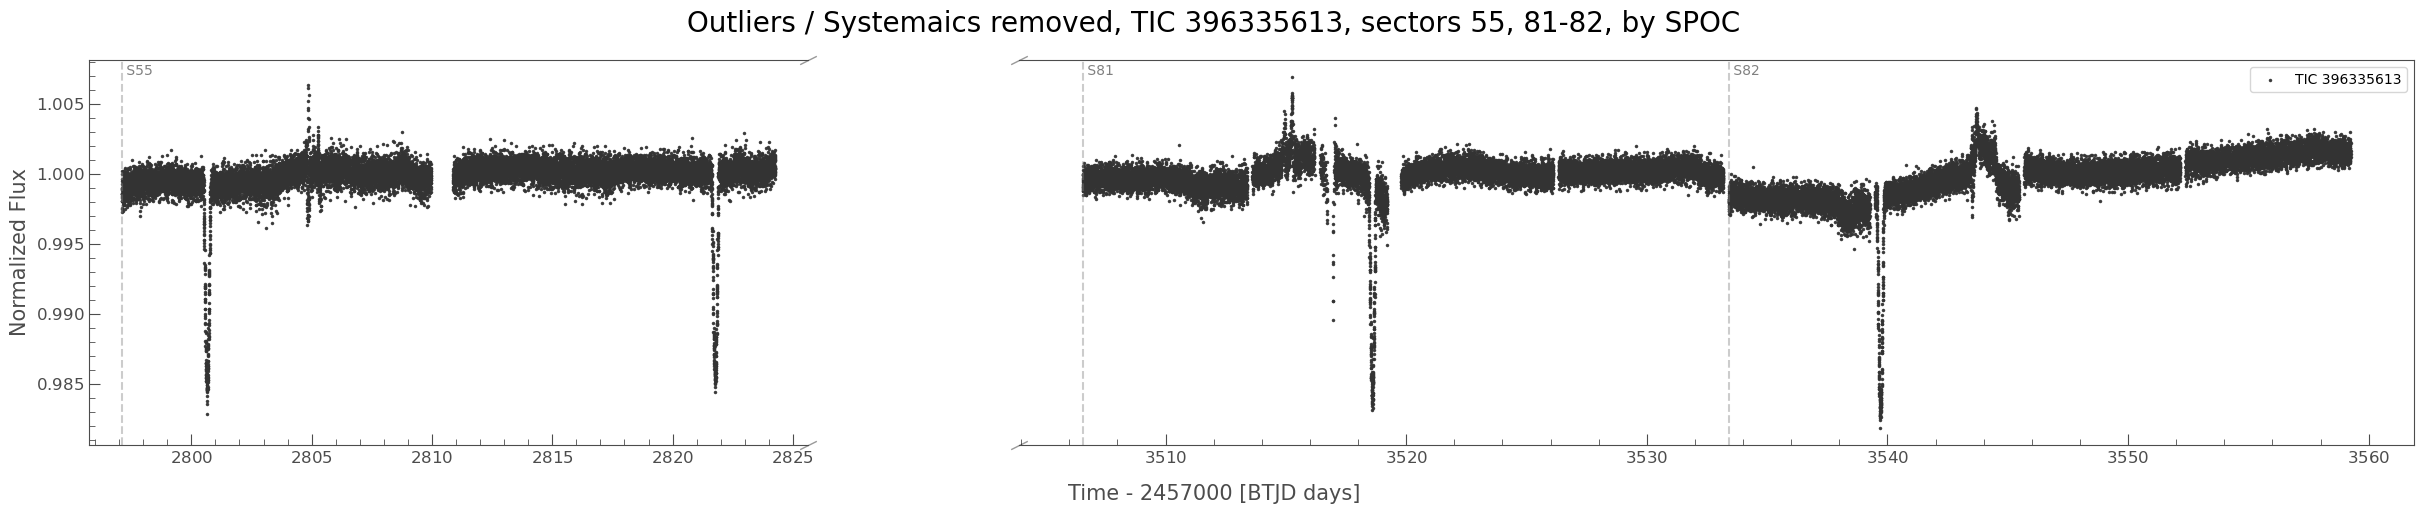

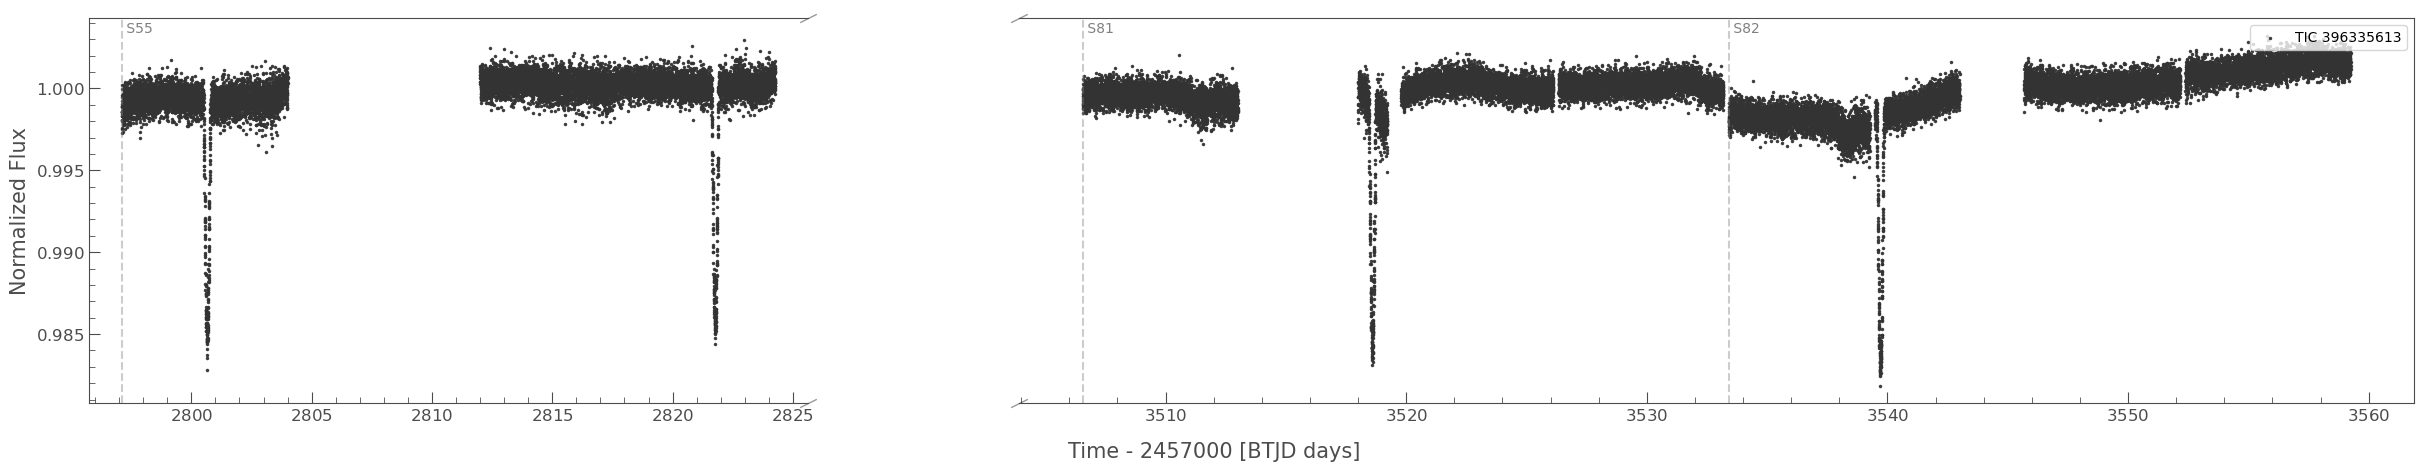

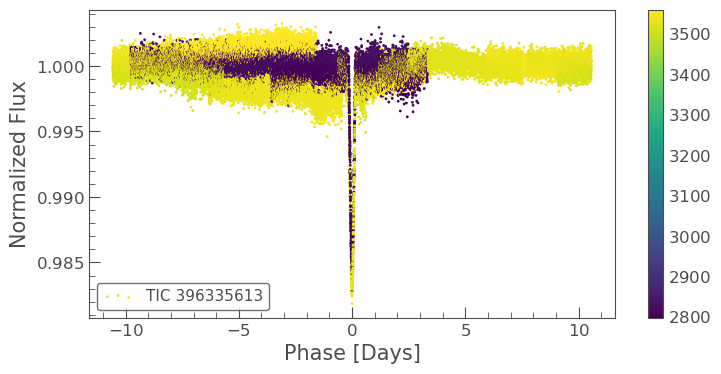

In [72]:
_lc = lke.stitch(lcc_tess, corrector_func=lambda lc: lc.select_flux("sap_flux").normalize(), ignore_incompatible_column_warning=True)  # 

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"All, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);

# axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
# axs[0].get_figure().suptitle(f"Y-zoom, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);
# [ax.set_ylim(0.97, 1.02) for ax in axs];

# _lc = _lc.truncate(0.97, 1.02, column="flux");
# some systematics near some of the eclipses are probably still there, e.g., around BTJD 3519, but I don't feel confident enough to remove them
for xstart, xstop in [  # scattered light, and systematics, use PDCSAP_FLUX as references
    (2804, 2812),
    (3513, 3518),
    (3543, 3545.5),
]:
    _lc = lke.exclude_range(_lc, xstart, xstop)

# # QLP sector 18 data has lone outliers associated with momentum dumps, exclude the time around them
# for t in np.unique(np.round(lket.MomentumDumpsAccessor.get_in_range(start=1790, end=1816), 2)):
#     _lc = lke.exclude_range(_lc, t - 0.05, t + 0.05)

ax = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"Outliers / Systemaics removed, {_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);

_lc_f = _lc.fold(period=21.116, epoch_time=Time(3539.71, format="btjd"), )  # wrap_phase= # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);


# convert to mag and HJD
lc_tess = _lc
lc_tess = lke.to_flux_in_mag_by_normalization(lc_tess)
lc_tess = lke.convert_lc_time_to_hjd_utc(lc_tess, target_coord=target_coord, cache_dir=lk_download_dir)
len(lc_tess)

### Do Actual combining

TESS # data points: 45116


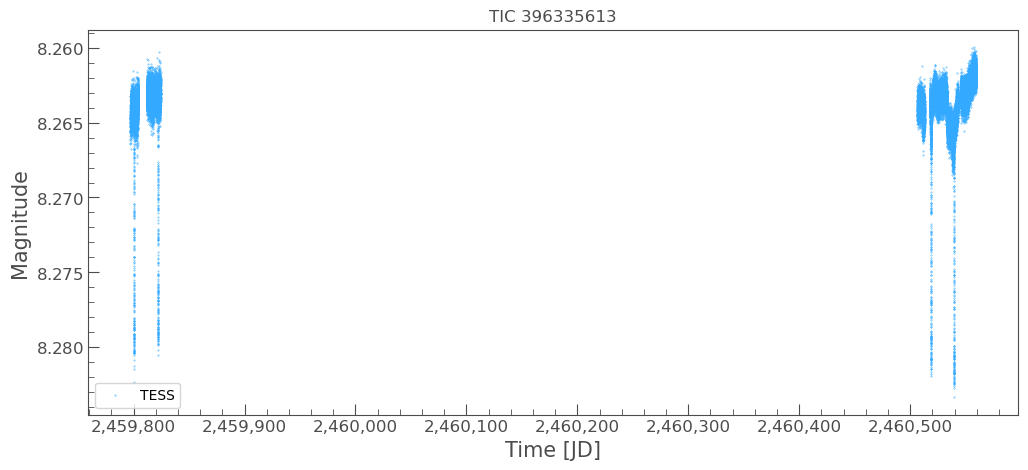

In [73]:
# Convert the data to magnitude and HJD/UTC

import lightkurve_ext_multi_sources as lkem
# reload(lkem)

lc_combined_dict = lkem.combine_multi_bands_and_shift(
    {"TESS": lc_tess, 
    }, 
    # shift_to="",
)

for k in lc_combined_dict.keys():
    print(f"{k} # data points:", len(lc_combined_dict[k]))

plot_options = lkem.get_default_plot_multi_bands_options_copy()
# for TESS plot (index 0) move it to the front
# plot_options[0][1]["zorder"] = 3  # default 2

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(12, 5), target_name=primary_name, plot_options=plot_options);
# ax.set_ylim(10.4, 10.25);

## Initial epoch / period / duration


Adopted period / epoch / duration_hr:  21.116 2460539.71 7.0


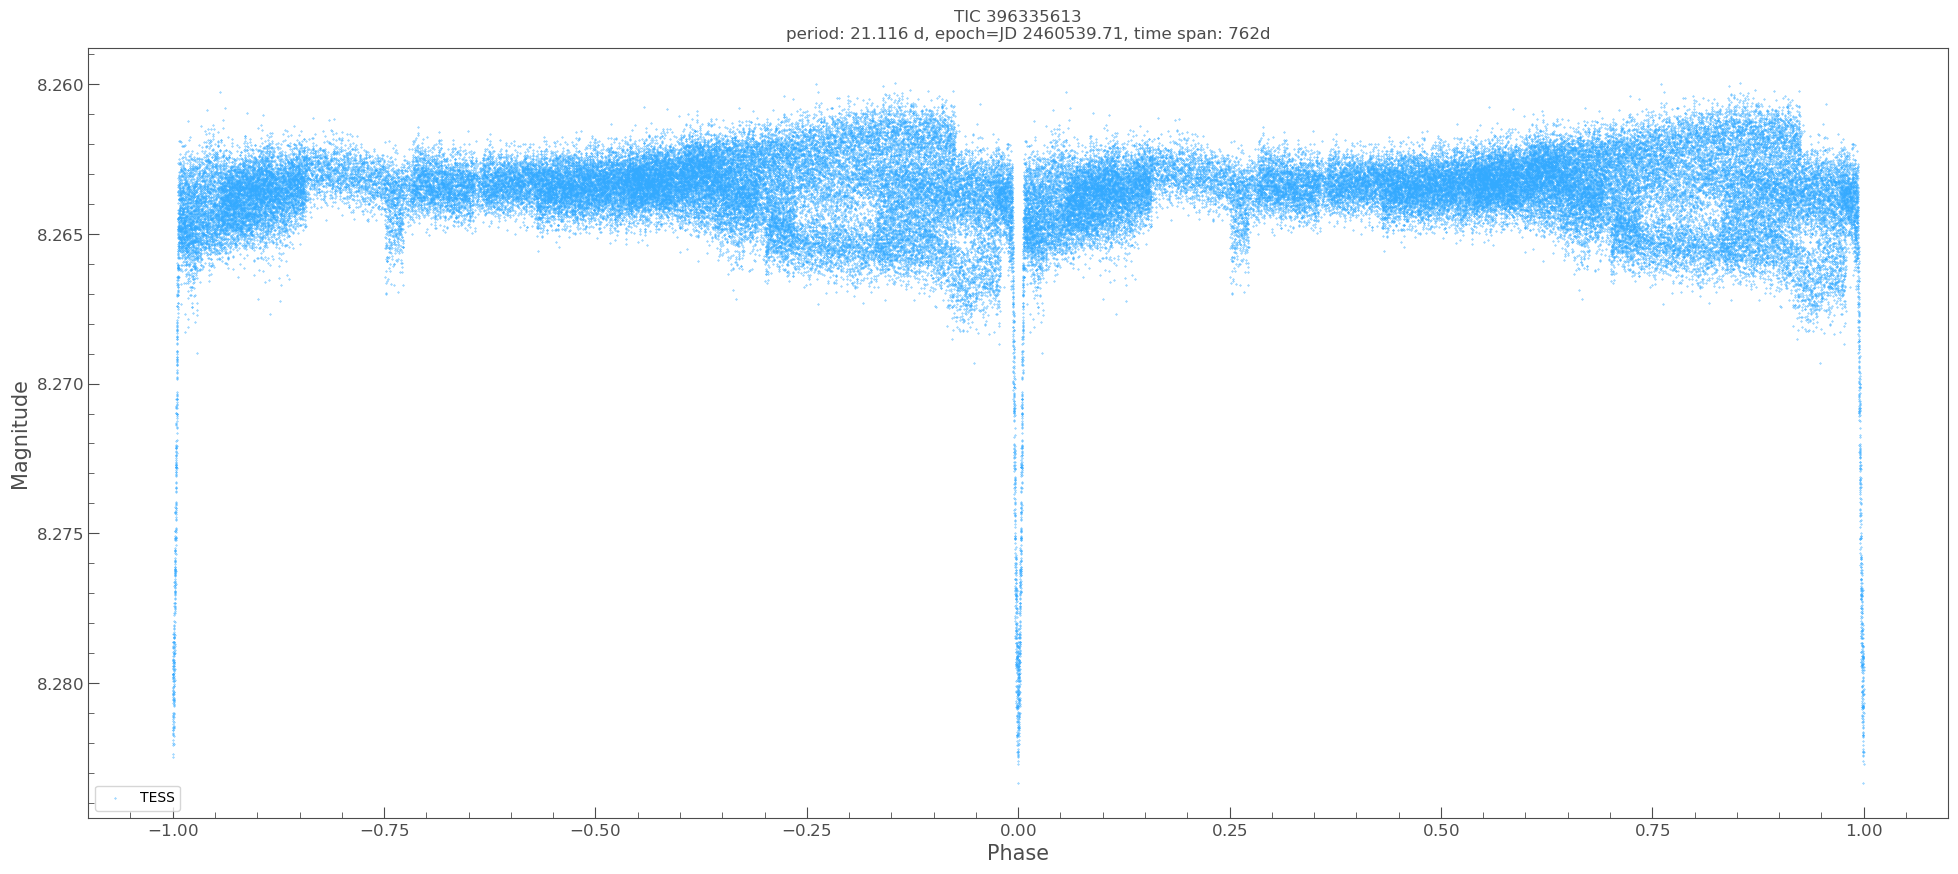

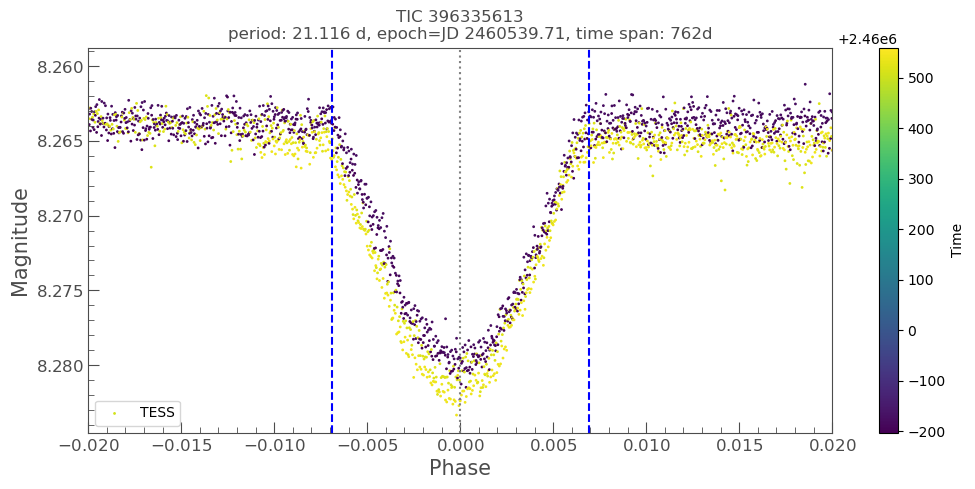

In [46]:
# reload(lkem)

# values from manual inspection
# (There are TCEs but no good period due to insufficient data in PDCSAP_FLUX)

period_trial = 21.116
epoch_time_btjd_trial = 3539.71
epoch_time_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_btjd_trial, target_coord), 2)  # need 2 digit to ensure it does look off visually
duration_hr_min_i_trial = 7.0

# # from visual inspection
# epoch_time_min_ii_btjd_trial = 
# epoch_time_min_ii_hjd_trial = round(lket.btjd_to_hjd_utc(epoch_time_min_ii_btjd_trial, target_coord), 2)  # need 3 digit to ensure it does look off visually
# duration_hr_min_ii_trial = 18.5


print("Adopted period / epoch / duration_hr: ", period_trial, epoch_time_hjd_trial, duration_hr_min_i_trial)  # , duration_hr_min_ii_trial

# --- Plot them to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 1
plot_options_zoom[0][1]["c"] = "_time_"

# plot_options_zoom[0][1]["zorder"] = 3  # move to the front, default 2
# plot_options_zoom[1][1].update(dict(marker='o', markersize=4))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5), 
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.02, 0.02);  # to see primary in details
ax.set_ylim(*ylim);


# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_trial,
#     epoch=Time(epoch_time_min_ii_hjd_trial, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     duration_hr=duration_hr_min_ii_trial  ,  # for plotting only
#     figsize=(12, 5),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_xlim(-0.015, 0.015);  # to see primary in details
# ax.set_ylim(9.3, None);


## Period refinement with MCMC

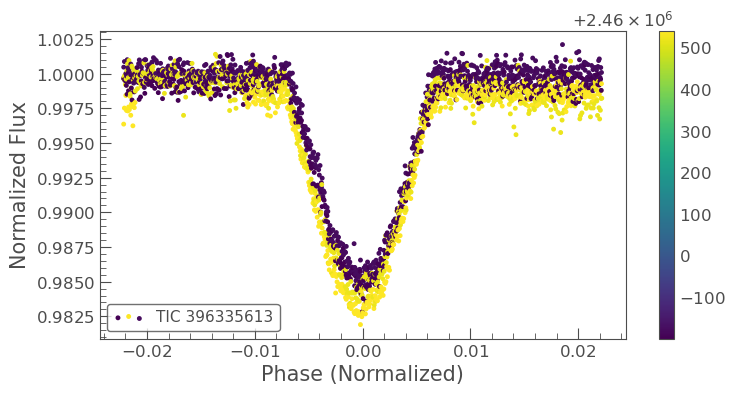

In [38]:
_lc = lke.stitch_lc_dict(lke.get_lc_dict_subset(lc_combined_dict, "TESS"), normalize=True).remove_nans()  

lc_f_min_i = _lc.fold(epoch_time=epoch_time_hjd_trial, period=period_trial, normalize_phase=True)
lc_f_min_i = lc_f_min_i.truncate((0 - duration_hr_min_i_trial / 24 * 1.5) / period_trial, (0 + duration_hr_min_i_trial /24 * 1.5) / period_trial)
# lc_f_min_i = lc_f_min_i.truncate(None, 1.2, column="flux")  # crude outlier removal
ax1 = tplt.scatter(lc_f_min_i, c=lc_f_min_i.time_original.value, s=25);
# ax1 = tplt.errorbar(lc_f_min_i);

In [40]:
from types import SimpleNamespace

import sys
if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
    sys.path.append("../eb_with_diff_sb_period/etv/")

import etv_functions_with_period as etvp
import etv_functions
# reload(etv_functions)

lc_f = lc_f_min_i

# # median flux, -eclipse depth, t0, related to duration, related to shape (U or V) 
# # t0 in normalixed phase
start_vals = [1.0, -0.016, 0, 0.004, 0.8]


# convert lc to the form needed by fit etv_functions
lc_f_data = SimpleNamespace(time=lc_f.time_original.value, phase=lc_f.time.value, flux=np.array(lc_f.flux.value), err=np.array(lc_f.flux_err.value))
etv_functions.plot_initial_guess_interactive(lc_f_data, None, None, None, "0", *start_vals)

Output(layout=Layout(padding='1em 0px'), outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Fig…

Output(layout=Layout(padding='1em'), outputs=({'name': 'stdout', 'text': '[1.0, -0.016, 0, 0.004, 0.8]\n\n', '…

### Final MCMC fit with the best initial period

100%|██████████████████████████████████████████████████████████| 2000/2000 [02:34<00:00, 12.90it/s]
The chain is shorter than 20 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/20 = 100;
tau: [ 98.60786734 206.87967383  64.75112157 209.22218908 214.90463967
  53.32342392]


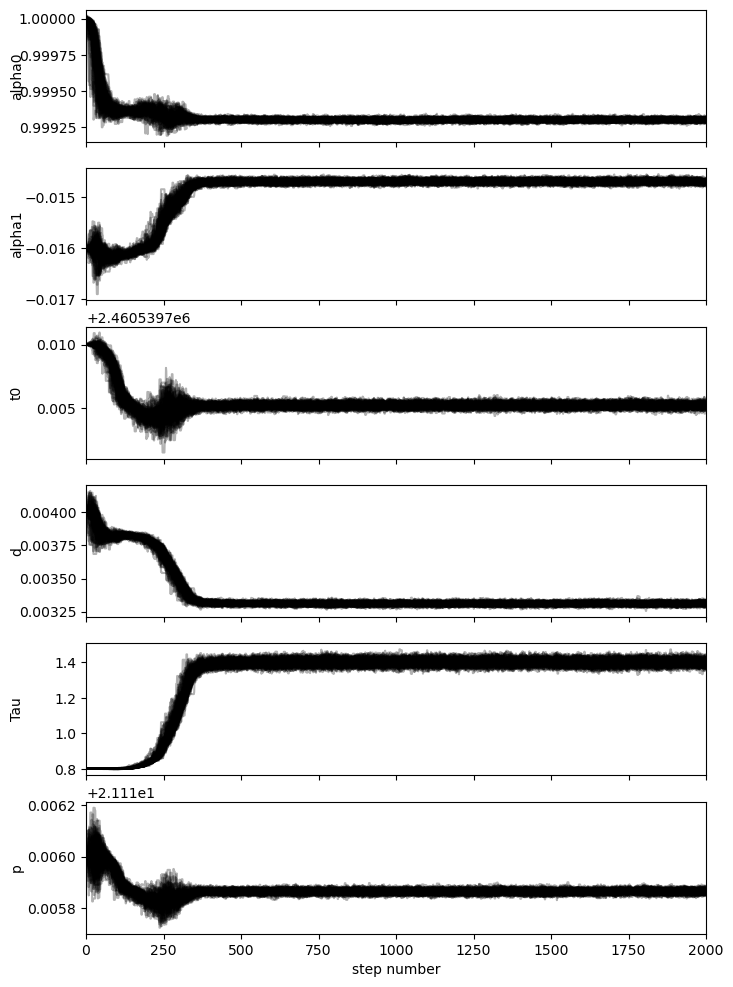

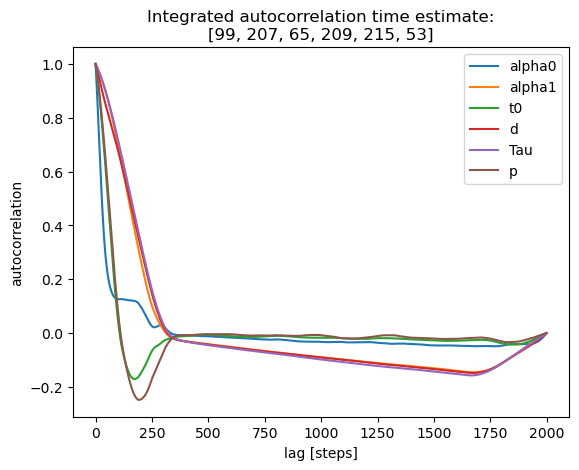

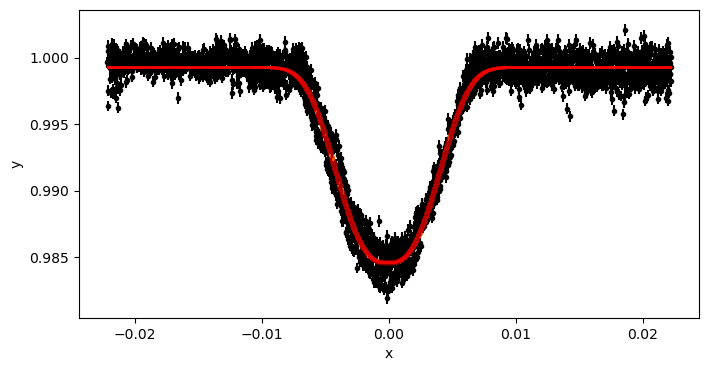

mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = 0.9992996500143922, -0.014692351835144316, 2460539.705221587, 0.003310850139142287, 1.3997890395939567, 21.115865018504962
std_t0: 0.00019228942608125318
std_p: 8.032695030493018e-06


In [42]:
mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p, fit_params_p_stats  = etvp.run_mcmc_initial_fit_p(
    lc_f_data, 
    [1.0, -0.016, epoch_time_hjd_trial, 0.004, 0.8, period_trial],
    # nruns=20, discard=1,
    nruns=2000, discard=1000,
    autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
    pool=-2, 
    plot_chains=True, plot_autocorrelation=True, plot=True, 
    also_return_stats=True,
)

print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p]]))
print("std_t0:", fit_params_p_stats["std_t0"])
print("std_p:", fit_params_p_stats["std_p"])


## Final period / epoch / duration

Adopted period / epoch / duration_hr:  21.1159 2460539.71 7.0


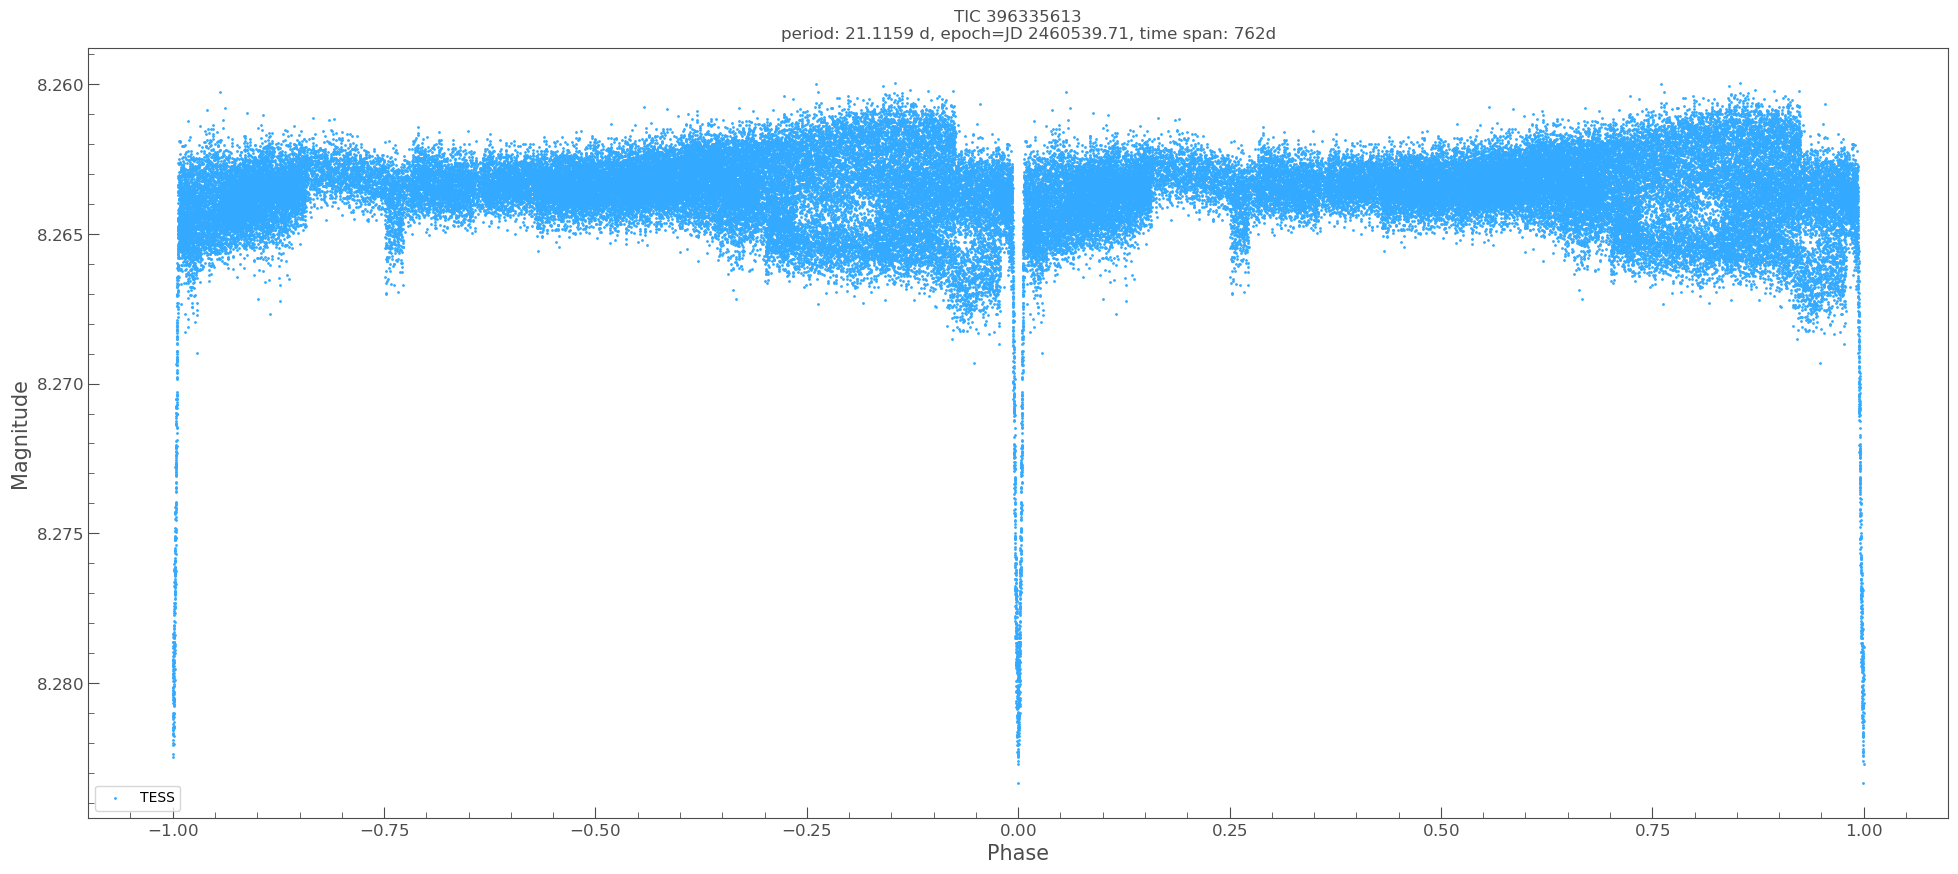

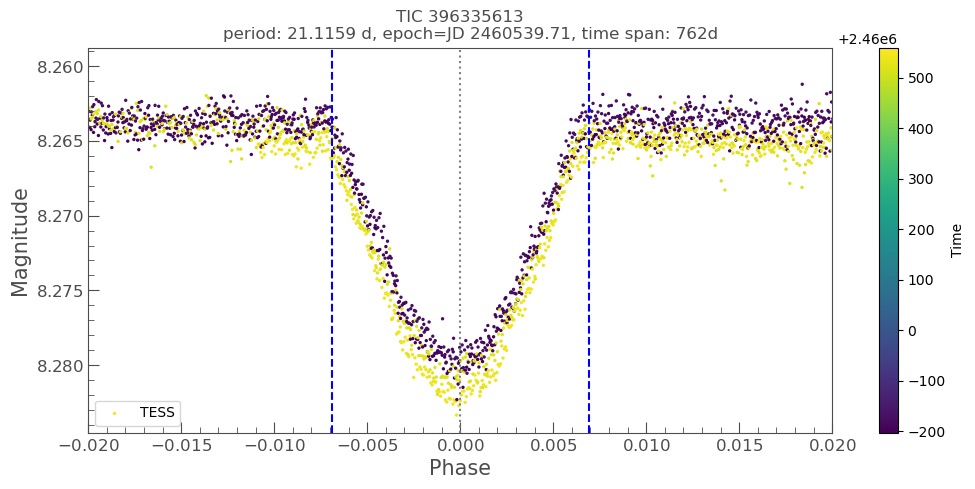

In [52]:
# reload(lkem)
from decimal import Decimal

# NCNMC values: p=21.115865018504962,  std_p: 8.032695030493018e-06, t0=2460539.705221587, std_t0: 0.00019228942608125318
period_final = 21.1159  # 21.11587  # visually 4 digits are sufficient
epoch_time_hjd_final = 2460539.71  # visually 2 digits are sufficient
duration_hr_min_i_final = duration_hr_min_i_trial 

# epoch_time_min_ii_hjd_final = epoch_time_min_ii_hjd_trial
# epoch_phase_min_ii_final   = abs(epoch_time_min_ii_hjd_final - float(epoch_time_hjd_final)  ) / period_final  % 1
# epoch_phase_min_ii_final  = round(epoch_phase_min_ii_final, 4)  # precsion from eyeballing zoomed plot
# duration_hr_min_ii_final = duration_hr_min_ii_trial


print("Adopted period / epoch / duration_hr: ", period_final, epoch_time_hjd_final, duration_hr_min_i_final)  #  epoch_phase_min_ii_final, , duration_hr_min_ii_final

# --- plot to verify ---

plot_options = lkem.get_default_plot_multi_bands_options_copy()
plot_options[0][1]["s"] = 1

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1]["s"] = 2
plot_options_zoom[0][1]["c"] = "_time_"


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.02, 0.02);  # to see primary in details
ax.set_ylim(*ylim);

# ax = tplt.scatter(lc_f_res["TESS"].truncate(-0.005, 0.005), c="#3AF");
# ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_title(f"Min I: {epoch_time_hjd_final}");

# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     duration_hr=duration_hr_min_ii_final  ,  # for plotting only
#     duration_midpoint_phase=epoch_phase_min_ii_final,
#     figsize=(12, 5),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
# ax.set_xlim(epoch_phase_min_ii_final - 0.01, epoch_phase_min_ii_final + 0.01);  # to see secondary in details
# ax.set_ylim(9.3, None);


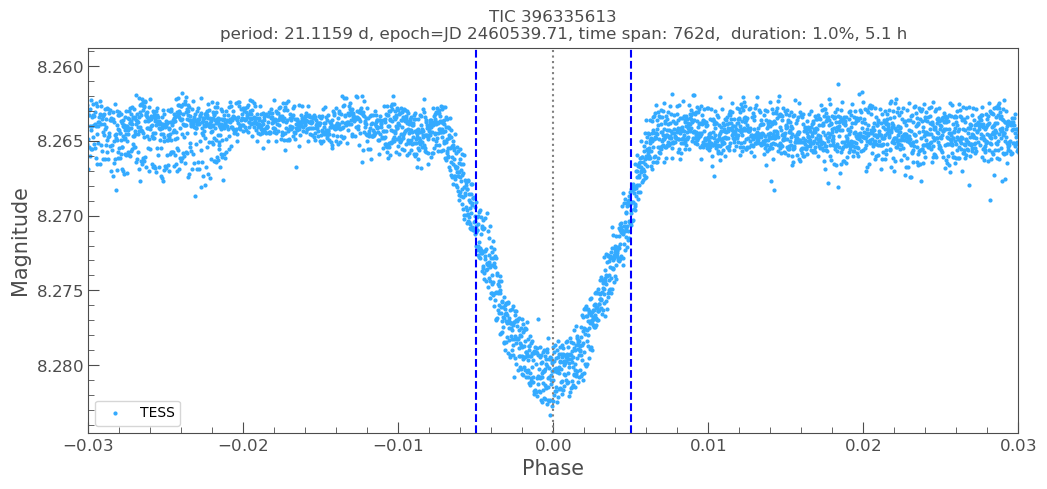

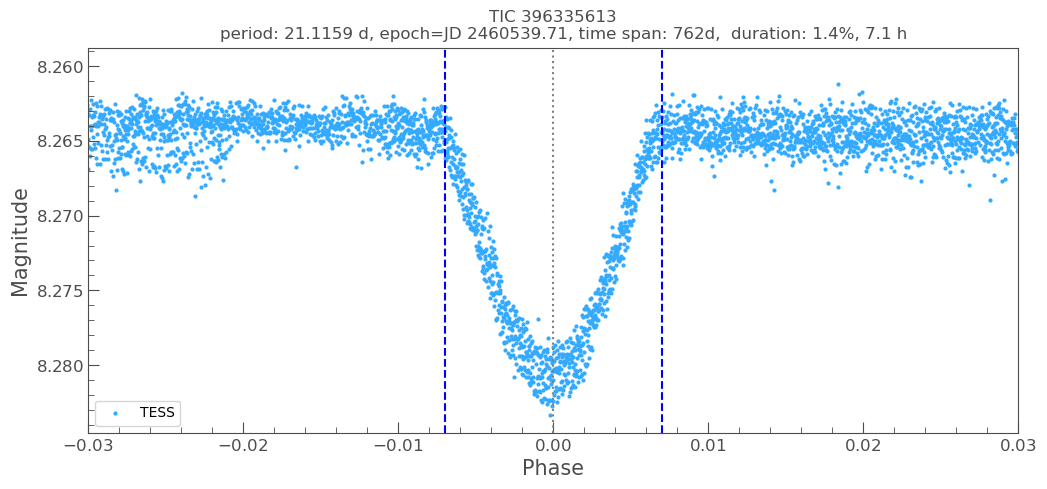

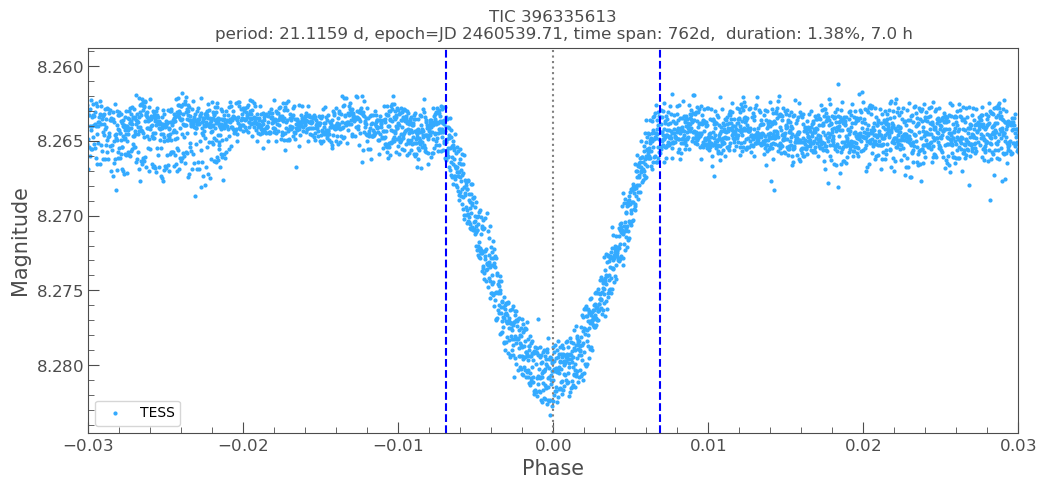

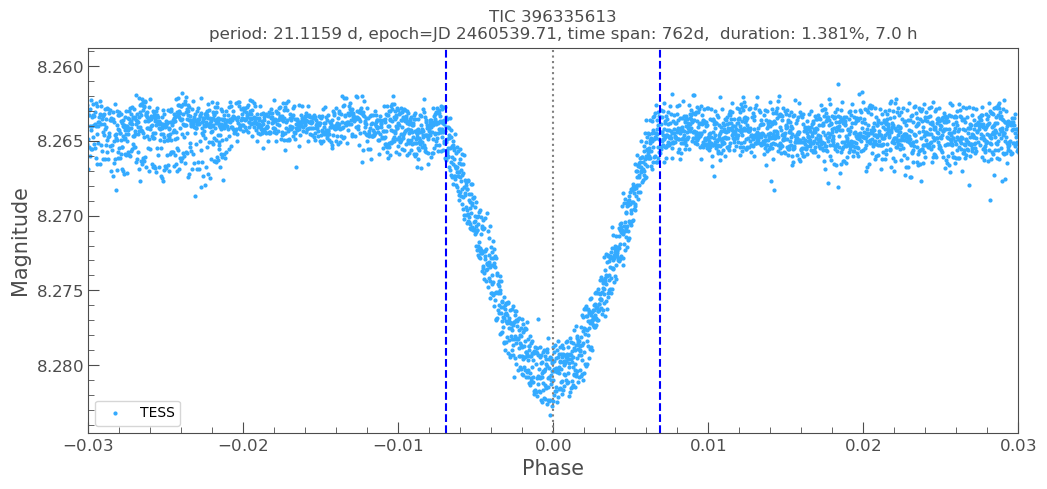

In [53]:
# demonstrate the precision difference in duration percentage 
# - 1 digit for percetnarge would be appropriate
for _precision in [0, 1, 2, 3]: 
    _dur_pct = round(100 * duration_hr_min_i_final / 24 / float(period_final), _precision)
    _dur_hr = _dur_pct /100 * 24 * float(period_final)
    # zoom plot Min I
    # - make TESS more visible:  larger dots
    plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
    plot_options_zoom[0][1]["s"] = 4
    ax, lc_f_res = lkem.fold_n_plot_multi_bands(
        lc_combined_dict,
        period=period_final,
        epoch=Time(epoch_time_hjd_final  , format="jd", scale="utc"),
        phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
        target_name=primary_name,
        duration_hr=_dur_hr,  # for plotting only
        figsize=(12, 5),
        plot_options=plot_options_zoom,
        # mag_shift_precision=2,  #
    );
    ax.set_ylim(*ylim);
    ax.legend(loc="lower left");
    ax.axvline(0, c="gray", linestyle="dotted");
    ax.set_xlim(-0.03, 0.03);  # to see primary in details
    ax.set_title(ax.get_title() + f",  duration: {_dur_pct}%, {_dur_hr:.1f} h");
    # print(_dur_pct, _dur_hr, duration_hr_min_i_final) 

## Determine Amplitude (TESS)


Min I mag # num data points: 32
['8.2635', '8.2804']


(0.017,)

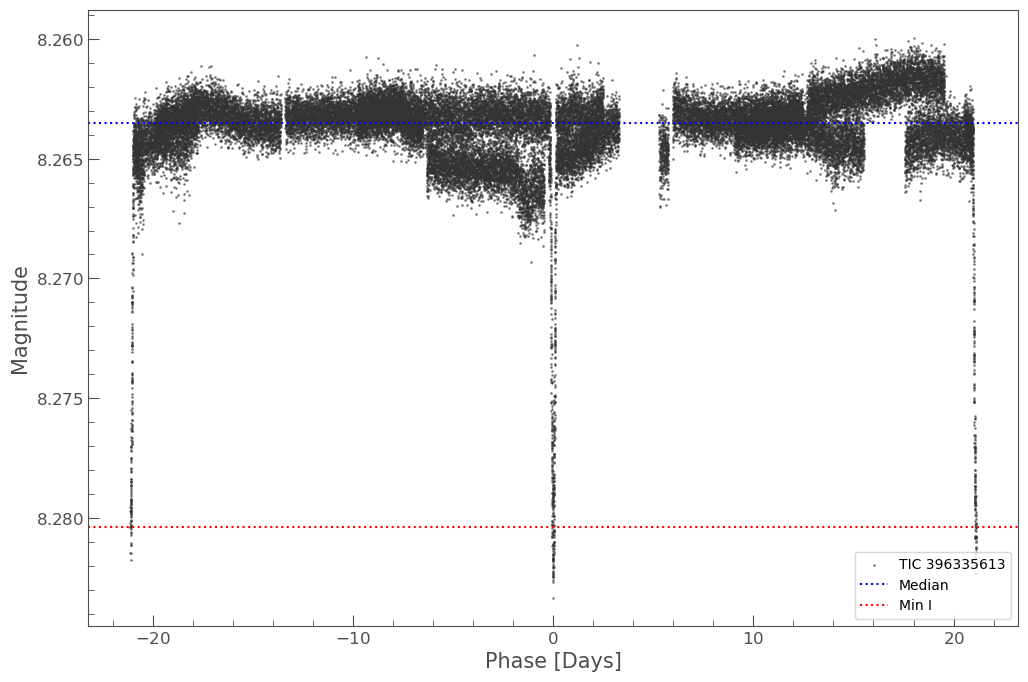

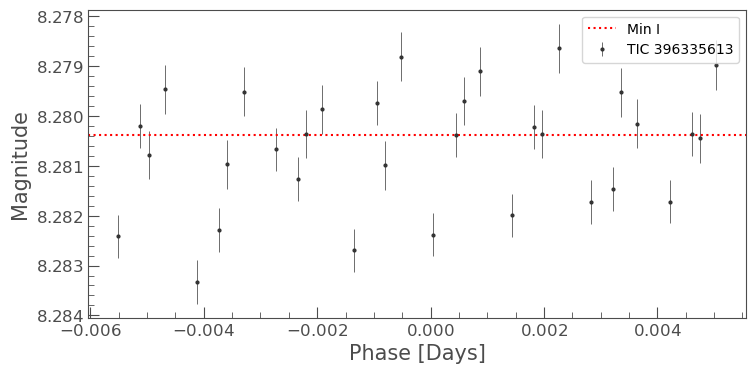

In [60]:
# %matplotlib widget
%matplotlib inline

# From TESS data
lc = lc_combined_dict["TESS"]

# max_flux_mag = lc.flux.min().value  #
# min_flux_mag = lc.flux.max().value
median_flux_mag = np.nanmedian(lc.flux.value)

# no max neded, medain is basically max
# lc_zoom_max = lc.fold(epoch_time=epoch_time_hjd_final + 0.75, period=period_final).truncate(0 - 1 /24/60, 0 + 1 /24/ 60)  
# print("Max mag # num data points:", len(lc_zoom_max))
# max_flux_mag = np.nanmedian(lc_zoom_max.flux.value)

lc_zoom_min = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final).truncate(0 - 8 /24/60, 0 + 8 /24/ 60)
print("Min I mag # num data points:", len(lc_zoom_min))
min_flux_mag = np.nanmedian(lc_zoom_min.flux.value)

# lc_zoom_min_ii = lc.fold(epoch_time=epoch_time_min_ii_hjd_final, period=period_final).truncate(0 - 4 /24/60, 0 + 4 /24/ 60)
# print("Min II mag # num data points:", len(lc_zoom_min_ii))
# min_ii_flux_mag = np.nanmedian(lc_zoom_min_ii.flux.value)


lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final * 2)  # 2x period plot
ax = tplt.lk_ax(figsize=(12, 8))
ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
# ax.axhline(max_flux_mag, c="purple", linestyle="--", label="Max")
ax.axhline(median_flux_mag, c="blue", linestyle="dotted", label="Median")
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
# ax.axhline(min_ii_flux_mag, c="orange", linestyle="dotted", label="Min II")
ax.legend(loc="lower right");
# ax.set_xlim(-0.5, 0.5); 
ax.set_ylim(*ylim);


ax = tplt.errorbar(lc_zoom_min, marker="o");
ax.axhline(min_flux_mag, c="red", linestyle="dotted", label="Min I")
# ax.set_ylim(*ylim);
ax.legend();

# ax = tplt.errorbar(lc_zoom_min_ii, marker="o");
# ax.axhline(min_ii_flux_mag, c="red", linestyle="dotted", label="Min II")
# ax.legend(loc="lower right");

print([f"{v:.4f}" for v in [median_flux_mag, min_flux_mag]])  # , min_ii_flux_mag


# # TESS only data, to report mean V mag and ampitude in TESS
# mean_flux_v_mag = np.round(rs_all_cols["Vmag"][0], 2)  # V converted from Gaia DR3 - here I use other sources

# amp_flux_mag = np.round(np.abs(float(min_flux_mag - max_flux_mag)) , 3)  # in TESS band, probably don't have 4 digit precison

amp_min_i_flux_mag = np.round(np.abs(float(min_flux_mag - median_flux_mag)) , 3)  # does not look like it has 3 digit precision given the out-of-eclipse variation

# amp_min_ii_flux_mag = np.round(np.abs(float(min_ii_flux_mag - median_flux_mag)) , 2)  

(amp_min_i_flux_mag, )  # amp_flux_mag, amp_min_ii_flux_mag

### Maximum / Median magnitude in V 

- GCPD entry:
  - https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-ref=VIZ6a18c3aa15e13b&-out.add=.&-source=II/167/catalog&recno=91564
  - https://gcpd.physics.muni.cz/cgi-bin/photoSys.cgi?phot=04&type=original&refer=with&mode=starno&ident=0100199238&rem=None
  - https://gcpd.physics.muni.cz/cgi-bin/photoSys.cgi?phot=79&type=original&refer=with&mode=starno&ident=0100199238&rem=None
- One of the GCPD entry is based on ubvy photometry, the y band is baiscally Johnson V (but narrower)
- Comparison:
  - Tycho-2 V in SIMBAD: 8.51
  - Gaia DR3 V: 8.52

In [61]:
median_flux_vmag = 8.54  # from GCPD
median_flux_vmag

8.54

## Plots for VSX

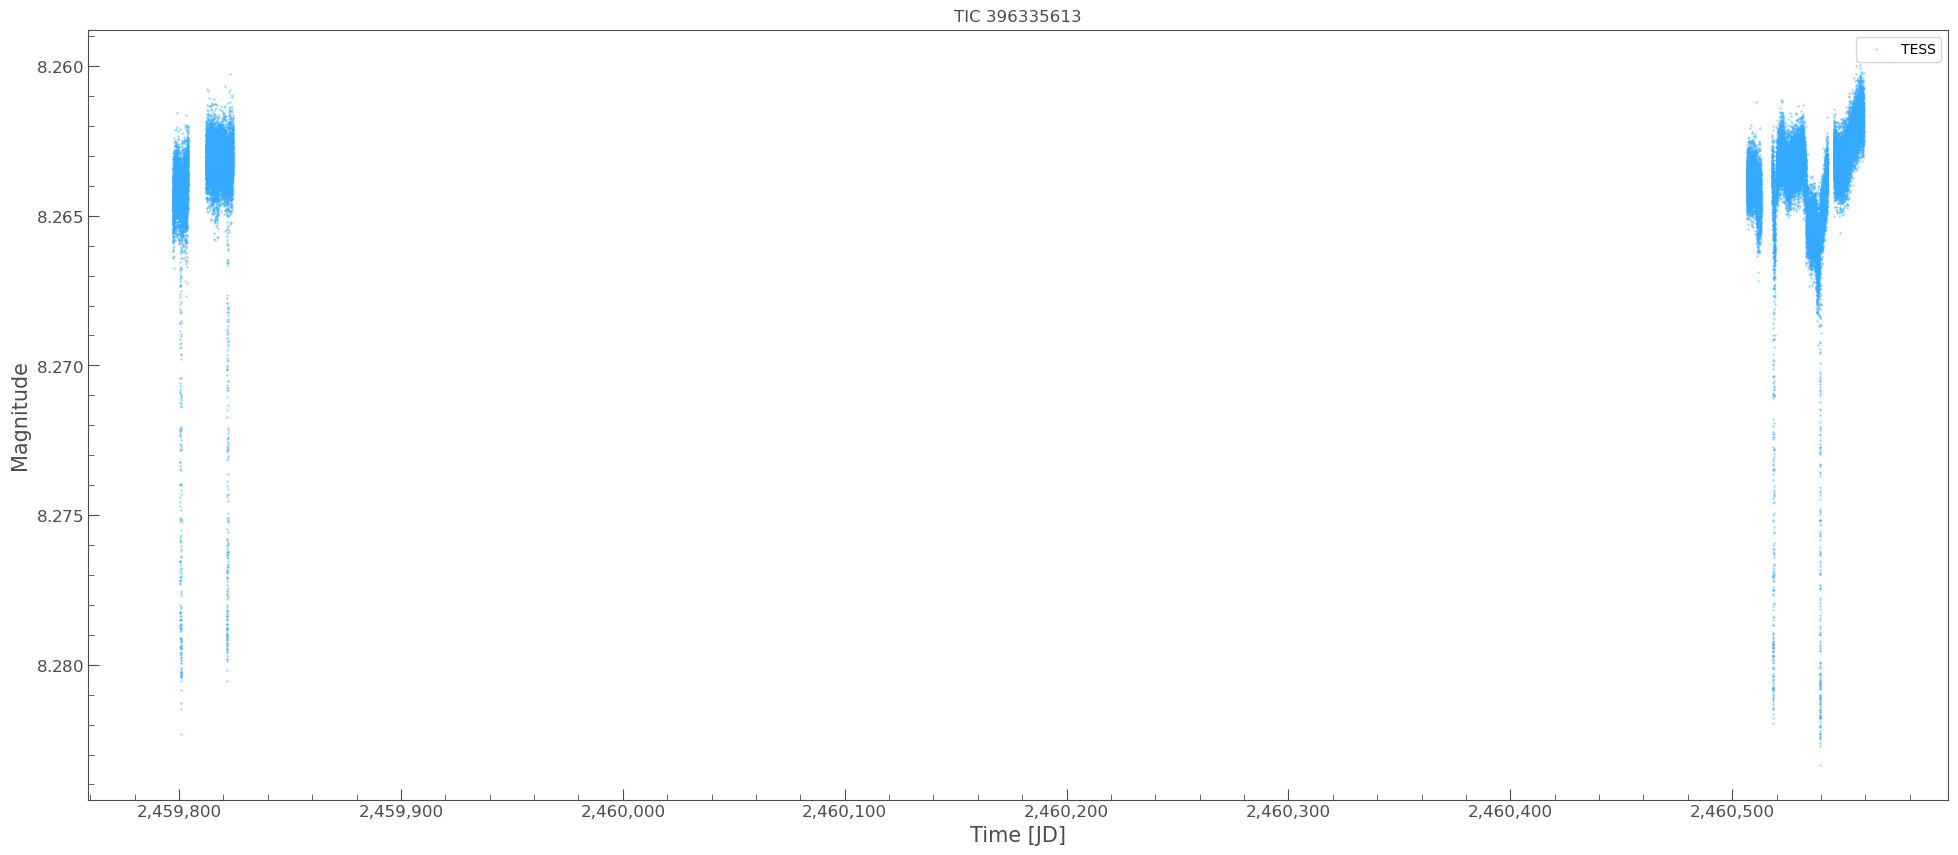

In [74]:
# reload(lkem)
# Not needed
plot_options = lkem.get_default_plot_multi_bands_options_copy()
# plot_options[0][1]["zorder"] = 4

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(24, 10), target_name=primary_name, plot_options=plot_options);
# ax.set_title(ax.get_title() + "");

#### Phase Plot



In [ ]:
lkem.get_default_plot_multi_bands_options_copy()

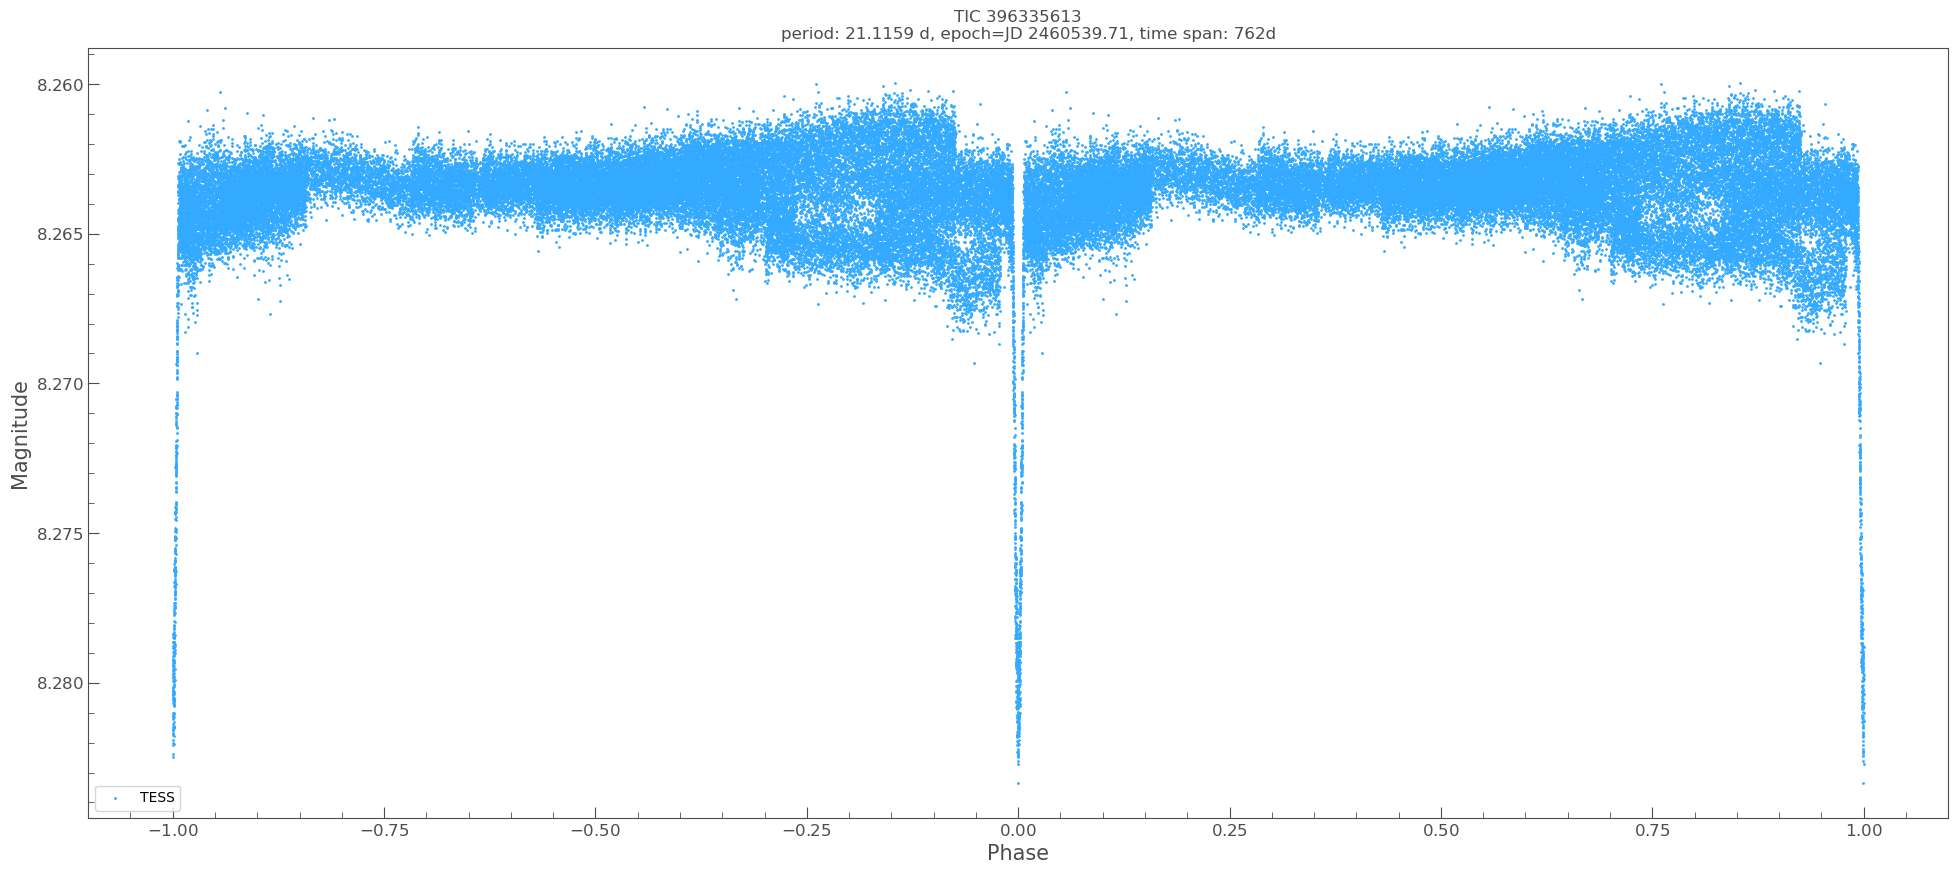

In [87]:
plot_options = lkem.get_default_plot_multi_bands_options_copy()  # use scatter plot , as errrobar is too busy
plot_options[0][1].update(dict(s=1, ))  # make dots larger # c="_time_"

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)  # hide the outliers that are too bright, mostly in ASAS-SN g
ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


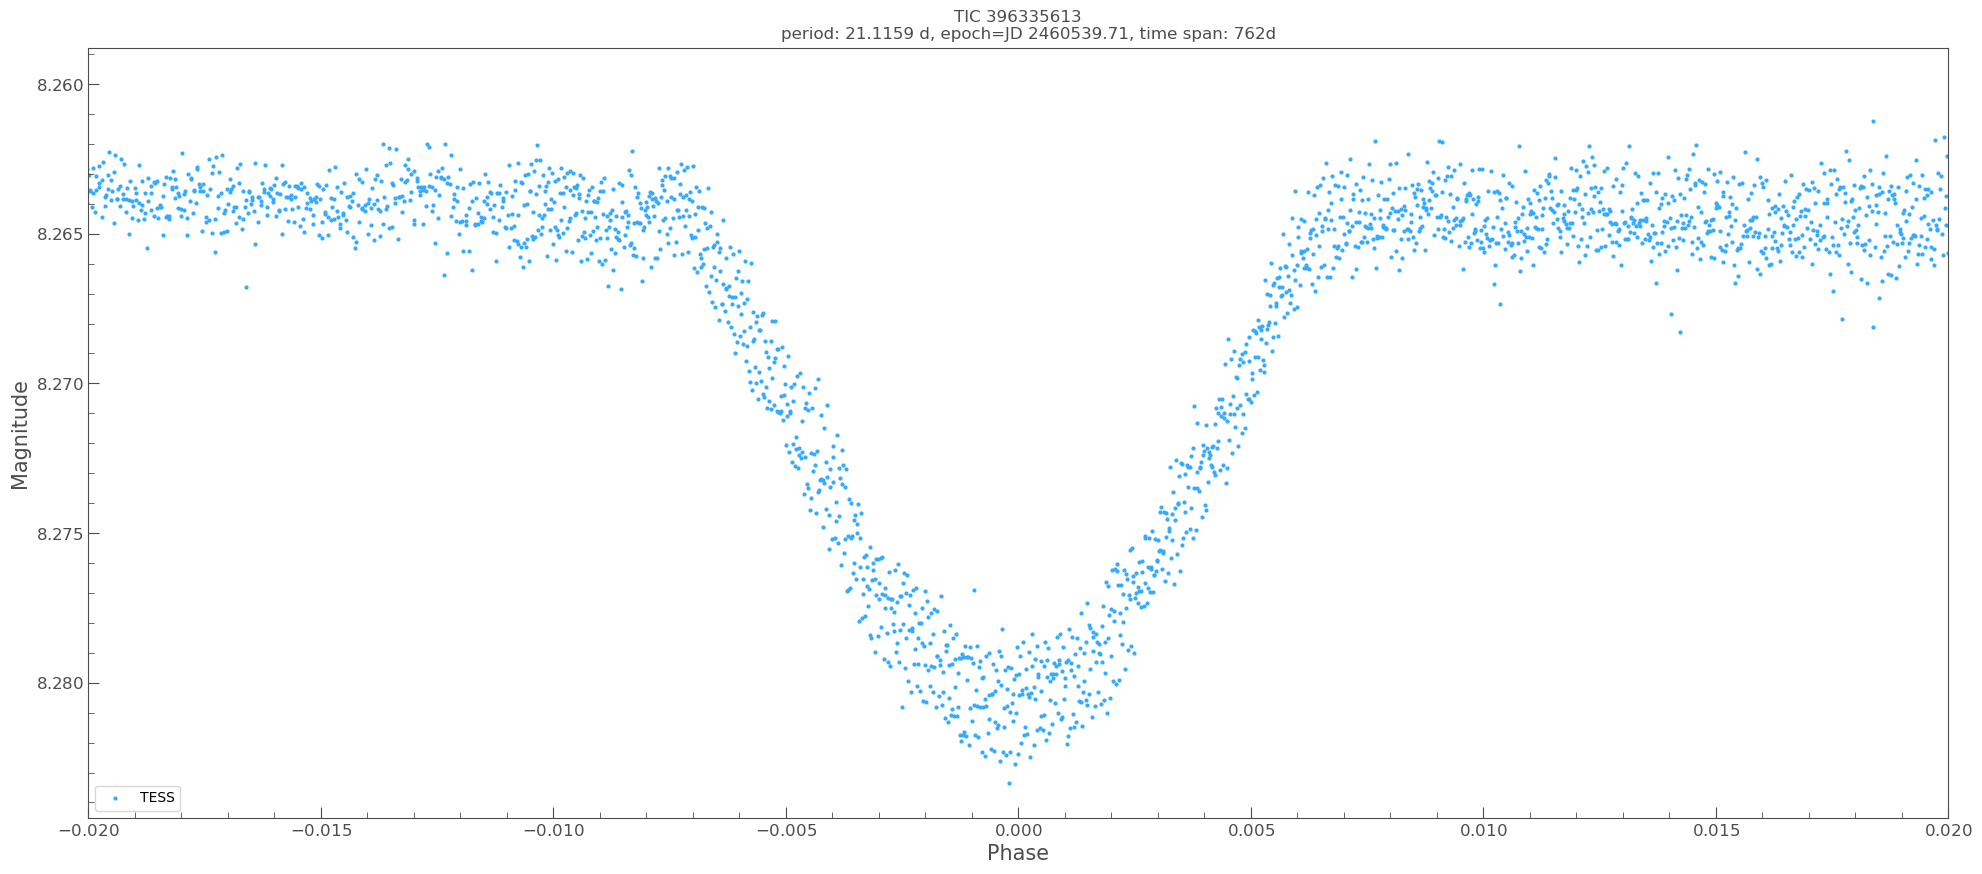

In [76]:
# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
plot_options_zoom[0][1].update(dict(s=4))
# plot_options_zoom[1][1].update(dict(marker='o', markersize=9))


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    # duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(24, 10),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
# ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.02, 0.02);  # to see primary in details
ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     # duration_hr=duration_hr_min_ii_final ,  # for plotting only
#     # duration_midpoint_phase=epoch_phase_min_ii_final,
#     figsize=(24, 10),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# # ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
# ax.set_xlim(epoch_phase_min_ii_final - 0.01, epoch_phase_min_ii_final + 0.01);  # to see secondary in details
# ax.set_ylim(9.3, None);
# # ax.set_title(ax.get_title() + ", outliers truncated");


### JD Plot (TESS) - N/A

In [ ]:
# # to show the eclipses and the time without eclipses
# axs = tplt.plot_skip_data_gap(lc_combined_dict["TESS"], figsize=(30, 4), s=2, c="#3AF", label=lkem.get_label_of_source(lc_combined_dict, "TESS", mag_shift_precision=2));
# axs[0].get_figure().suptitle(f"{primary_name}");

## VSX Report Table

In [77]:
def report_to_df(report):
    df = pd.DataFrame()
    df["Field"] = report.keys()
    df["Value"] = report.values()
    return df


def vsx_phase(phase):
    # the phase I used above is from [-0.5, +0.5]
    # convert to the phase [0, 1[ used by VSX
    if phase < -0.5 or phase > 0.5:
        raise ValueError(f"Input phase needs to be in [-0.5, 0.5] range. Actual: {phase}")
    if phase >= 0:
        return phase 
    else: 
        return 1 + phase


In [86]:
import bibs_utils
# reload(bibs_utils)


other_names = "HIP 103313,2MASS J20555020+0323340,TYC 517-1806-1" # in ExoFOP and SIMBAD
other_names += ",HD 199238,BD+02 4275,GSC 00517-01806,SAO 126375"  # other useful names in SIMBAD
other_names += ",UCAC4 467-127118"  # in ExoFOP and UCAC4  -- https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-ref=VIZ6a18d39f346eb0&-out.add=.&-source=I/322A/out&UCAC4===467-127118
# note: name "uvby98 100199238" is somewhat useful: it's one of the sources of GCPD, but probably excessive to be incldued

remarks = (
    f"""Period might be twice the given value."""
)

# Not neeed for initial submission:
# - Type, period, epoch, eclipse duration from TESS data. Amplitude from TESS data.
revision_comment = "Maximum magnitude derived from GCPD. Spectral type from 1999MSS...C05....0H. Gaia DR3 position."

# Reference note:
# - also listed in TESS Ten Thousand Catalog: Eclipsing Binaries (Kostov+, 2025), but only as an unvalidated and unvetted entry (with no epoch, period, etc.)
# so it's ignored.
#   - https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-ref=VIZ6a18bb585b1fb&-out.add=.&-source=J/ApJS/279/50/table2&recno=708645
# - in NSVS, but error seems to be too large
#   - https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-ref=VIZ6a18d3b23482e5&-out.add=.&-source=II/287/skydot&recno=14316721

BIBS = bibs_utils.BIBS
vsx_report = dict(
    Position=f"{target_coord.ra.value:.5f}, {target_coord.dec.value:.5f}",  # VSX coordinate precision
    Primary_Name=primary_name,
    Other_Names=other_names,
    Variable_Type="EA",
    Spectral_Type="A3/5II",  # 1999MSS...C05....0H , in SIMBAD  -- https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-source=III/214/vol5&HD=199238%20
    Spectral_Type_Uncertain=False,
    Maximum_Magnitude=f"{median_flux_vmag}",  # from GCPD
    Maximum_Magnitude_band="V",
    Minimum_Magnitude=f"{amp_min_i_flux_mag}",
    Minimum_Magnitude_band="TESS",  
    Minimum_Is_Amplitude=True,
    Period=f"{period_final}",  
    Period_Uncertain=False,
    Epoch=f"{epoch_time_hjd_final}",  
    Rise_Duration_Pct=f"{100 * duration_hr_min_i_final / 24 / float(period_final):.1f}",  # 1 decimal point is enough visually
    Discoverer="Sam Lee, Planet Hunters TESS Collaboration",  # PHT Talk:  https://www.zooniverse.org/projects/nora-dot-eisner/planet-hunters-tess/talk/2112/3917387?comment=6440750
    Remarks=remarks,
    Revision_Comment=revision_comment,
    Reference0_Name=BIBS.TESS_N,
    Reference0_Bib=BIBS.TESS_B,
    Reference1_Name="Houk, N.; Swift, C., 1999, Michigan catalogue of two-dimensional spectral types for the HD Stars, Vol. 5",
    Reference1_Bib="1999MSS...C05....0H",
)


def print_long_fields(report):
    other_names_list = report["Other_Names"].split(",")
    print("Other Names (1 line each):")
    print("\n".join(other_names_list))
    print("")
    print(report["Remarks"])
    print("")
    print(report["Revision_Comment"])

print_long_fields(vsx_report)
with pd.option_context('display.max_colwidth', None):
    display(report_to_df(vsx_report))


print("""
tic396335613_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS data (SPOC SAP_FLUX), some systematics removed.
tic396335613_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS data. Zoomed around Min I.
""")


Other Names (1 line each):
HIP 103313
2MASS J20555020+0323340
TYC 517-1806-1
HD 199238
BD+02 4275
GSC 00517-01806
SAO 126375
UCAC4 467-127118

Period might be twice the given value.

Maximum magnitude derived from GCPD. Spectral type from 1999MSS...C05....0H. Gaia DR3 position.


,Field,Value
0,Position,"313.95923, 3.39280"
1,Primary_Name,TIC 396335613
2,Other_Names,"HIP 103313,2MASS J20555020+0323340,TYC 517-1806-1,HD 199238,BD+02 4275,GSC 00517-01806,SAO 126375,UCAC4 467-127118"
3,Variable_Type,EA
4,Spectral_Type,A3/5II
5,Spectral_Type_Uncertain,False
6,Maximum_Magnitude,8.54
7,Maximum_Magnitude_band,V
8,Minimum_Magnitude,0.017
9,Minimum_Magnitude_band,TESS



tic396335613_phase_plot_eclipses.png : EA Phase Plot - EA Phase Plot from TESS data (SPOC SAP_FLUX), some systematics removed.
tic396335613_phase_plot_eclipses_zoom_min_i.png : EA Phase Plot (Min I Zoom) - EA Phase Plot from TESS data. Zoomed around Min I.

